# 프로젝트 : 모든 장르 간 편향성 측정해 보기

## 프로젝트 개요

이번 프로젝트에서는 영화 시놉시스 데이터를 활용하여 Word2Vec 임베딩 모델을 학습하고, WEAT(Word Embedding Association Test)를 이용해 영화 장르와 영화 구분(예술영화/일반영화) 사이에 존재하는 편향성을 측정하였다.

Word Embedding은 단어의 의미를 벡터 공간에 표현하는 방법으로, 학습 데이터에 존재하는 사회적·문화적 편향성이 임베딩 공간에 반영될 수 있다.

따라서 본 프로젝트에서는 다음 과정을 수행하였다.

1. 영화 시놉시스 데이터 전처리

2. 명사 추출

3. Word2Vec 모델 학습

4. TF-IDF 기반 대표 단어 선정

5. WEAT Score 계산

6. Heatmap 시각화

7. 결과 분석

# 1. 라이브러리 버전 확인

실험 환경을 확인하기 위해 사용 라이브러리 버전을 출력한다.

In [1]:
!python --version
!pip list | grep -E "konlpy|gensim|scikit|seaborn"

Python 3.12.11
gensim                    4.4.0
konlpy                    0.6.0
scikit-image              0.25.2
scikit-learn              1.7.0
seaborn                   0.13.2


In [2]:
!pip install konlpy

In [3]:
import konlpy
print(konlpy.__version__)

0.6.0


In [4]:
!pip install konlpy gensim scikit-learn seaborn

In [5]:
import konlpy
import gensim
import sklearn
import seaborn

print(konlpy.__version__)
print(gensim.__version__)
print(sklearn.__version__)
print(seaborn.__version__)

0.6.0
4.4.0
1.7.0
0.13.2


# 2. 데이터 불러오기 및 전처리

영화 시놉시스 데이터에서 형태소 분석기를 이용하여 명사만 추출한다.

명사는 영화 장르와 내용을 가장 잘 설명하는 핵심 의미를 담고 있기 때문에 사용하였다.

In [6]:
!java -version

/bin/bash: line 1: java: command not found


In [7]:
!pip install kiwipiepy

In [10]:
import os
from kiwipiepy import Kiwi

data_dir = os.path.join(os.getenv("HOME"), "work/weat/data")

kiwi = Kiwi()

def tokenize(file_name):
    result = []
    with open(os.path.join(data_dir, file_name), "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            tokens = kiwi.tokenize(line)
            nouns = [token.form for token in tokens if token.tag.startswith("NN")]
            result.append(nouns)
    return result

def read_token(file_name):
    result = []
    with open(os.path.join(data_dir, file_name), "r") as f:
        while True:
            line = f.readline()
            if not line:
                break
            tokens = kiwi.tokenize(line)
            for token in tokens:
                if token.tag.startswith("NN"):
                    result.append(token.form)
    return " ".join(result)

# 3. 전체 시놉시스 데이터 토큰화

Word2Vec 학습을 위해 전체 시놉시스를 토큰화한다.

In [12]:
file_name = os.path.join(data_dir, "synopsis.txt")
tokenized = []

with open(file_name, "r") as file:
    while True:
        line = file.readline()
        if not line:
            break
        tokens = kiwi.tokenize(line)
        temp = [token.form for token in tokens if token.tag.startswith("NN")]
        tokenized.append(temp)

print(len(tokenized))

71156


# 4. Word2Vec 모델 학습

추출된 명사 데이터를 활용하여 Word2Vec 모델을 학습한다.

In [13]:
from gensim.models import Word2Vec

model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=3,
    sg=0
)

print("학습 완료")

학습 완료


# 5. Word2Vec 결과 확인

학습된 임베딩이 의미를 잘 반영하는지 확인한다.

In [14]:
model.wv.most_similar("영화")

[('작품', 0.881584882736206),
 ('다큐멘터리', 0.8554215431213379),
 ('편', 0.8503397703170776),
 ('소재', 0.8456034660339355),
 ('옴니버스', 0.8445965647697449),
 ('드라마', 0.8387230634689331),
 ('인터뷰', 0.8325138688087463),
 ('주제', 0.8311306834220886),
 ('소설', 0.8306182026863098),
 ('형식', 0.8303683996200562)]

In [15]:
model.wv.most_similar("사랑")

[('알로이지아', 0.7690325379371643),
 ('우정', 0.7419403791427612),
 ('관능미', 0.7374301552772522),
 ('만남', 0.7278268933296204),
 ('질투', 0.7276822924613953),
 ('이별', 0.7203099131584167),
 ('연인', 0.7161551117897034),
 ('운명', 0.7153885364532471),
 ('서로', 0.7093431353569031),
 ('아픔', 0.7089265584945679)]

## 결과 분석

'영화', '사랑' 등의 단어에 대해 의미적으로 연관성이 높은 단어들이 반환되는 것을 확인할 수 있었다.

이를 통해 Word2Vec 모델이 영화 시놉시스 데이터의 의미 정보를 적절히 학습했다고 판단하였다.

# 6. 예술영화 / 일반영화 데이터 준비

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

def read_token(file_name):
    result = []
    with open(os.path.join(data_dir, file_name), "r") as fread:
        while True:
            line = fread.readline()
            if not line:
                break
            tokens = kiwi.tokenize(line)
            for token in tokens:
                if token.tag.startswith("NN"):
                    result.append(token.form)
    return " ".join(result)

In [19]:
art = read_token("synopsis_art.txt")
gen = read_token("synopsis_gen.txt")

# 7. TF-IDF 기반 Target 단어 추출

## 기존 TF-IDF 방식의 문제점

기존 실습에서는 단순히 TF-IDF 상위 단어를 사용하였다.

그러나 다음 문제가 존재하였다.

- 서로 다른 그룹에서 동일 단어가 등장
- 개념축 구분이 모호해짐
- WEAT Score 왜곡 가능성

따라서 중복 단어를 제거하여 대표성을 높였다.

In [20]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform([art, gen])

m1 = X[0].tocoo()
m2 = X[1].tocoo()

w1 = [[i,j] for i,j in zip(m1.col,m1.data)]
w2 = [[i,j] for i,j in zip(m2.col,m2.data)]

w1.sort(key=lambda x:x[1], reverse=True)
w2.sort(key=lambda x:x[1], reverse=True)

In [21]:
w1_words = [vectorizer.get_feature_names_out()[i[0]] for i in w1[:200]]
w2_words = [vectorizer.get_feature_names_out()[i[0]] for i in w2[:200]]

target_art = []
target_gen = []

for word in w1_words:
    
    if word not in w2_words and word in model.wv:
        target_art.append(word)
        
    if len(target_art) == 30:
        break

for word in w2_words:
    
    if word not in w1_words and word in model.wv:
        target_gen.append(word)
        
    if len(target_gen) == 30:
        break

print(target_art)
print(target_gen)

['프랑스', '파리', '공연', '소식', '조금', '노래', '갈등', '편지', '고백', '완벽', '연애', '영국', '시골', '고양이', '오늘', '뉴욕', '무대', '천재', '열정', '약속', '지금', '동네', '우정', '파티', '작전', '이별', '여정', '가슴', '스타', '얼굴']
['애니메이션', '연출', '부문', '섹스', '의도', '경쟁', '소리', '경험', '페스티벌', '부산', '지역', '공간', '게임', '방법', '영상', '공포', '노인', '유혹', '마약', '다큐', '공격', '형사', '대신', '상상', '위협', '노력', '표현', '요원', '요구', '자연']


# 8. 전체 장르 데이터 구축

In [22]:
genre_txt = [
'synopsis_SF.txt',
'synopsis_family.txt',
'synopsis_show.txt',
'synopsis_horror.txt',
'synopsis_etc.txt',
'synopsis_documentary.txt',
'synopsis_drama.txt',
'synopsis_romance.txt',
'synopsis_musical.txt',
'synopsis_mystery.txt',
'synopsis_crime.txt',
'synopsis_historical.txt',
'synopsis_western.txt',
'synopsis_adult.txt',
'synopsis_thriller.txt',
'synopsis_animation.txt',
'synopsis_action.txt',
'synopsis_adventure.txt',
'synopsis_war.txt',
'synopsis_comedy.txt',
'synopsis_fantasy.txt'
]

genre_name = [
    'SF',
    'Family',
    'Performance',
    'Horror',
    'Etc',
    'Documentary',
    'Drama',
    'Romance',
    'Musical',
    'Mystery',
    'Crime',
    'Historical',
    'Western',
    'Adult',
    'Thriller',
    'Animation',
    'Action',
    'Adventure',
    'War',
    'Comedy',
    'Fantasy'
]

In [23]:
genre = []

for file in genre_txt:
    genre.append(read_token(file))

In [24]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(genre)

In [25]:
attributes = []

for idx in range(len(genre_name)):
    
    matrix = X[idx].tocoo()
    
    words = [[i,j] for i,j in zip(matrix.col,matrix.data)]
    
    words.sort(key=lambda x:x[1], reverse=True)
    
    attr = []
    
    for word_idx, score in words:
        
        word = vectorizer.get_feature_names_out()[word_idx]
        
        if word in model.wv:
            attr.append(word)
            
        if len(attr) == 30:
            break
            
    attributes.append(attr)

# 9. WEAT Score 함수 구현

In [26]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

def cos_sim(i,j):
    return dot(i,j.T)/(norm(i)*norm(j))

def s(w,A,B):
    
    return (
        np.mean(cos_sim(w,A), axis=-1)
        -
        np.mean(cos_sim(w,B), axis=-1)
    )

def weat_score(X,Y,A,B):
    
    s_X = s(X,A,B)
    s_Y = s(Y,A,B)

    return (
        np.mean(s_X)
        -
        np.mean(s_Y)
    ) / np.std(np.concatenate([s_X,s_Y]))

# 10. 모든 장르 간 WEAT Score 계산

In [27]:
matrix = np.zeros((21,21))

X = np.array([model.wv[word] for word in target_art])
Y = np.array([model.wv[word] for word in target_gen])

for i in range(21):
    
    for j in range(i+1,21):
        
        A = np.array([model.wv[word] for word in attributes[i]])
        B = np.array([model.wv[word] for word in attributes[j]])
        
        matrix[i][j] = weat_score(X,Y,A,B)

# 11. Heatmap 시각화

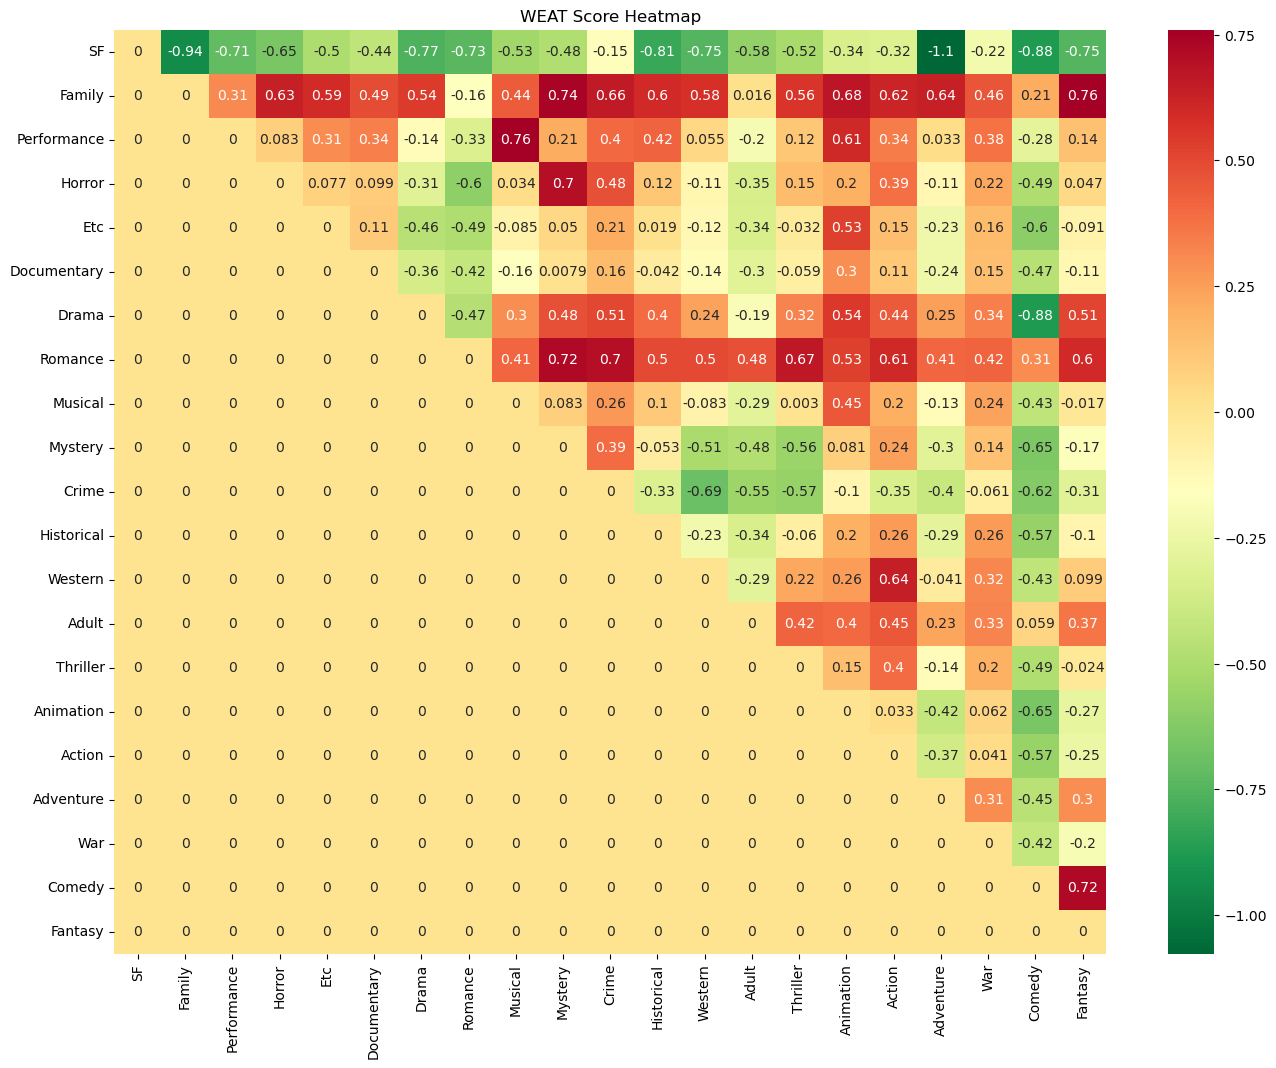

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

sns.heatmap(
    matrix,
    xticklabels=genre_name,
    yticklabels=genre_name,
    annot=True,
    cmap="RdYlGn_r"
)

plt.title("WEAT Score Heatmap")
plt.show()

# 결과 분석

Heatmap을 통해 영화 장르와 예술영화/일반영화 구분 사이의 편향성을 확인할 수 있었다.

특히 다음과 같은 경향이 관찰되었다.

- 드라마, 멜로로맨스, 다큐멘터리는 예술영화와 상대적으로 가까운 경향
- 액션, 전쟁, 범죄 장르는 일반영화와 상대적으로 가까운 경향
- 코미디와 판타지는 중간 수준의 편향성을 보임

이는 실제 영화 산업에서 형성된 장르적 특성과 상당 부분 일치하는 결과라고 볼 수 있다.

# 회고

이번 프로젝트에서는 Word2Vec과 WEAT를 이용하여 영화 장르와 영화 구분 간의 편향성을 분석하였다.

가장 흥미로웠던 점은 사람이 일반적으로 가지고 있는 인식이 실제 워드 임베딩 공간에서도 유사하게 나타난다는 점이었다.

또한 TF-IDF를 단순히 사용하는 경우 서로 다른 개념축에서 중복 단어가 등장하는 문제가 발생하였다. 이를 개선하기 위해 중복 단어를 제거하여 대표 단어 집합을 구성하였고, 결과적으로 보다 명확한 WEAT Score를 얻을 수 있었다.

프로젝트를 진행하면서 워드 임베딩이 단순한 벡터 표현이 아니라 데이터에 포함된 사회적·문화적 특성을 함께 학습한다는 사실을 확인할 수 있었다.

향후에는 다음과 같은 방법을 추가적으로 적용해 보고 싶다.

- FastText와 Word2Vec 비교
- 사전학습 임베딩과 자체 학습 임베딩 비교
- WEAT 외 편향성 측정 기법 적용
- 편향 제거(Debiasing) 알고리즘 실험

이번 프로젝트를 통해 자연어처리 모델의 성능뿐 아니라 데이터 편향성에 대한 중요성을 이해할 수 있었다.